# Baseline Metrics: Diversity, Perplexity, Coherence, Q*Text

- External baselines to contextualize diversity vector
- Definitions from Garces Arias et al., 2025: Towards Better Open-Ended Text Generation: A Multicriteria Evaluation Framework

| Metric | Formula | Direction |
|---|---|---|
| Diversity | $\text{DIV}(x) = \prod_{n=2}^{4} \dfrac{\lvert\text{unique } n\text{-grams}(x)\rvert}{\lvert\text{total } n\text{-grams}(x)\rvert}$ | higher = more lexically varied |
| Perplexity | $P(W) = \exp\left(-\dfrac{1}{N}\sum_{i=1}^N \log p(w_i \mid w_1,\dots,w_{i-1})\right)$ | lower = more predictable/fluent |
| Coherence | $\text{Coherence}(\hat x, x) = \dfrac{1}{\lvert\hat x\rvert}\sum_{i=1}^{\lvert\hat x\rvert}\log p_M(\hat x_i \mid [x:\hat x_{<i}])$ | higher = better conditioned on prompt |
| Q*Text | $\dfrac{\sum_{i=1}^{3} w_i M_i P_i(M_i)}{\sum_{i=1}^{3} w_i}$, with $P_i(x)=\exp(-\alpha_i(x-\mu_i)^2)$ | 0–100, weighted combination of the three metrics above |

**Deviations from the paper:**
- **OPT-2.7B** as a scorer for both Coherence and Perplexity (paper itself uses OPT-2.7B for Coherence, but self-perplexity for Perplexity)
- Q*Text reuses the paper's published fitted parameters -> refitting on this data not possible as there are no human judgements

**Data**
Generated data from `data_generation/generations/` switchable via `DOMAIN`:
- **`storytelling_n200`**: WritingPrompts (Fan et al., 2018) test split, 200 prompts x 4 LLMs x 5 samples + >=5 human reference stories/prompt
- **`translation_ref3`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=3 human translations/paragraph
- **`translation_ref4`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=4 human translations/paragraph

In [1]:
# Load libraries
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
# kruskal removed (significance testing dropped)
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

/Users/thwin/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Print-oriented plotting defaults: figures are sized close to their intended print width

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10})

tqdm.pandas()

In [3]:
# Configuration
DOMAIN = 'translation_ref3'  # 'storytelling_n200', 'translation_ref3' or 'translation_ref4'

SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
N_PROMPTS = 200


In [4]:
# Plot Configurations
FIG_DIR = Path(f'../../figures/baseline_metrics/{DOMAIN}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path(f'../../metrics/04_baseline_metrics/tables/{DOMAIN}')
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'facebook/opt-2.7b'   # shared scorer for Coherence & Perplexity, matches the paper's own Coherence scorer
MODEL_TAG = MODEL_NAME.split('/')[-1]  # short tag for cache/output filenames, e.g. 'opt-2.7b'
MAX_TOKENS = 256                   # matches the paper's generation length cap

# Device priority: CUDA (NVIDIA GPU) > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('Configuration:')
print(f'  Domain:     {DOMAIN}')
print(f'  Sources:    {SOURCES}')
print(f'  Scorer:     {MODEL_NAME} on {DEVICE}')
print(f'  Max tokens: {MAX_TOKENS}')

Configuration:
  Domain:     translation_ref3
  Sources:    ['human', 'llama', 'mistral', 'qwen', 'gemma']
  Scorer:     facebook/opt-2.7b on mps
  Max tokens: 256


## Load Dataset

In [5]:
# Repo root importable regardless of the kernel's working directory
import sys

def find_repo_root(start=None):
    start = Path(start or Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/' and "
                             "'data_generation/generations/')")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from common import data_prep
from common import MODEL_LABELS, MODEL_COLORS, MODEL_ORDER

DATA_DIR = data_prep.GENERATIONS_DIR / DOMAIN
print(f"DOMAIN = {DOMAIN!r}  ({DATA_DIR})")

# Canonical load: quality filter (model: truncation / language drift; human: language drift +
# exact-duplicate) + storytelling human 5-cap
# 'prompt' carries the conditioning context for Coherence.
_df = data_prep.load_texts(DOMAIN, n_prompts=N_PROMPTS)
df = _df[['prompt_id', 'source', 'story_id', 'prompt', 'text']].reset_index(drop=True)
df['model'] = df['source'].map(MODEL_LABELS)

n_dropped = {s: 5 * N_PROMPTS - int((df.source == s).sum()) for s in SOURCES if s != 'human'}
print(f'Loaded: {len(df)} texts ({df["prompt_id"].nunique()} prompts x {len(SOURCES)} sources)')
print(f'Dropped (quality filter): {n_dropped}')
print(df.groupby('source').size())
df.head(3)

DOMAIN = 'translation_ref3'  (/Users/thwin/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/data_generation/generations/translation_ref3)
Loaded: 4403 texts (200 prompts x 5 sources)
Dropped (quality filter): {'llama': 9, 'mistral': 27, 'qwen': 166, 'gemma': 64}
source
gemma      936
human      669
llama      991
mistral    973
qwen       834
dtype: int64


,prompt_id,source,story_id,prompt,text,model
0,0,human,0,"Впрочем, что ж я? — все это делают; болезнями-...",Though – what am I saying? – everyone does it;...,Human
1,0,human,1,"Впрочем, что ж я? — все это делают; болезнями-...","Why do I say that, though? Everybody does it –...",Human
2,0,human,2,"Впрочем, что ж я? — все это делают; болезнями-...","But, gentlemen, whoever can pride himself on h...",Human


In [6]:
# Fingerprint the exact loaded text rows so a corpus change (quality filter, human cap, seed)
# forces fresh caches instead of silently reusing stale per-text values under the same key
DATA_FINGERPRINT = data_prep.dataframe_fingerprint(df, cols=['prompt_id', 'source', 'story_id', 'text'])
print(f'Dataset fingerprint: {DATA_FINGERPRINT}')

Dataset fingerprint: d343da2915178f56


## Diversity: n-gram Repetition Rates

$$\text{DIV}(x) = \prod_{n=2}^{4} \frac{|\text{unique } n\text{-grams}(x)|}{|\text{total } n\text{-grams}(x)|}$$

- Purely lexical, no model needed
- Word tokens via a plain whitespace split (case and attached punctuation kept, e.g. "Text." and "text" count as distinct tokens)

In [7]:
# Word tokenizer: plain whitespace split, so case and attached punctuation are kept
def word_tokenize_simple(text):
    return text.strip().split()

def diversity_score(text, n_range=(2, 3, 4)):
    '''Calculate the diversity score of a text based on unique n-grams for n in n_range.'''
    tokens = word_tokenize_simple(text)
    score = 1.0

    for n in n_range:
        # Only consider n-grams if there are enough tokens
        if len(tokens) < n:
            return np.nan
    
        # Create n-grams
        ngrams = list(zip(*(tokens[i:] for i in range(n))))
        unique = len(set(ngrams))
        
        # Calculate the diversity score as the ratio of unique n-grams to total n-grams
        score *= unique / len(ngrams)
    return score


df['Diversity'] = df['text'].progress_apply(diversity_score)
print(df['Diversity'].describe())

100%|██████████| 4403/4403 [00:00<00:00, 7767.12it/s]

count    4403.000000
mean        0.915250
std         0.109144
min         0.010365
25%         0.903754
50%         0.936057
75%         0.962267
max         1.000000
Name: Diversity, dtype: float64


## Load the Fixed External Scorer (OPT-2.7B)

In [8]:
# float16 on MPS/GPU to keep the 2.7B-parameter model's memory footprint manageable (CPU stays float32)
SCORER_DTYPE = torch.float16 if DEVICE.type != 'cpu' else torch.float32

# Load the shared OPT-2.7B model for scoring Coherence and Perplexity
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=SCORER_DTYPE).to(DEVICE)
model.eval()

# Context-window field differs by architecture (GPT-2: n_positions, OPT/most others: max_position_embeddings)
CTX_LIMIT = getattr(model.config, 'n_positions', None) or model.config.max_position_embeddings


print(f'{MODEL_NAME} loaded on {DEVICE} ({SCORER_DTYPE}, context window: {CTX_LIMIT} tokens)')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 517/517 [00:00<00:00, 40028.34it/s]


facebook/opt-2.7b loaded on mps (torch.float16, context window: 2048 tokens)


## Perplexity: Self-Predictability of the Continuation

- Computed on generated text alone (no prompt context), truncated to `MAX_TOKENS`
- Uses OPT-2.7B's built-in cross-entropy loss ( = mean negative log-likelihood over the shifted sequence)

In [9]:
# Compute perplexity using the scorer model
@torch.no_grad()
def compute_perplexity(text, max_tokens=MAX_TOKENS):
    ''' Compute the perplexity of a text using the scorer model. Returns NaN if the text is too short.'''

    # Input text to model and compute loss
    input_ids = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_tokens)['input_ids'].to(DEVICE)

    # Only compute perplexity if the text has at least 2 tokens
    if input_ids.shape[1] < 2:
        return np.nan

    # Compute the loss and convert it to perplexity
    loss = model(input_ids, labels=input_ids).loss

    return float(torch.exp(loss).cpu())

# Load or compute perplexity (cached per domain + scorer model + MAX_TOKENS + corpus fingerprint,
# so a corpus change -- e.g. the human 5-cap -- can never silently reuse a stale cache)

CACHE_PATH = TABLE_DIR / f'baseline_metrics_results_{MODEL_TAG}_mt{MAX_TOKENS}_{DATA_FINGERPRINT}.csv'
KEY_COLS = ['prompt_id', 'source', 'story_id']

# Load cached perplexity if available, otherwise compute it for each text
if CACHE_PATH.exists():
    cached = pd.read_csv(CACHE_PATH)[KEY_COLS + ['Perplexity']]
    df = df.merge(cached, on=KEY_COLS, how='left')

    print(f'Loaded cached Perplexity for {df["Perplexity"].notna().sum()}/{len(df)} texts (skipped recomputation)')

else:
    df['Perplexity'] = df['text'].progress_apply(compute_perplexity)

print(df['Perplexity'].describe())

100%|██████████| 4403/4403 [1:16:33<00:00,  1.04s/it]

count    4403.000000
mean       24.296643
std         9.034528
min         5.899046
25%        18.165315
50%        22.574179
75%        28.603801
max        97.753639
Name: Perplexity, dtype: float64


## Coherence: Log-Likelihood of the Continuation Given the Prompt

$$\text{Coherence}(\hat x, x) = \frac{1}{|\hat x|}\sum_{i=1}^{|\hat x|} \log p_M(\hat x_i \mid [x : \hat x_{<i}])$$

- Prompt and continuation are each truncated to `MAX_TOKENS` & concatenated    
-> Only the log-probabilities of the continuation tokens (conditioned on the prompt) are averaged
- Conditioning text $x$ is the writing prompt for `storytelling_n200` or the source-language paragraph (`source_text`) for translation

In [10]:
@torch.no_grad()
def compute_coherence(prompt, text, max_tokens=MAX_TOKENS):
    ''' Compute the coherence of a text given a prompt using the scorer model. Returns NaN if the text is too short.'''

    # Tokenize the prompt
    prompt_ids = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=max_tokens)['input_ids']

    # Tokenize the continuation text and check if it has at least 1 token.
    # add_special_tokens=False: some tokenizers (e.g. OPT's, which prepends </s> as BOS) would
    # otherwise insert a spurious special token right at the prompt/continuation boundary below
    cont_ids = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_tokens, add_special_tokens=False)['input_ids']

    # Only compute coherence if the continuation has at least 1 token
    if cont_ids.shape[1] < 1:
        return np.nan

    # Concatenate prompt and continuation
    input_ids = torch.cat([prompt_ids, cont_ids], dim=1)
    prompt_len = prompt_ids.shape[1]

    # Ensure the input does not exceed the model's context window
    ctx_limit = CTX_LIMIT
    if input_ids.shape[1] > ctx_limit:

        # Truncate the input to fit within the context window, keeping the last `ctx_limit` tokens
        overflow = input_ids.shape[1] - ctx_limit
        input_ids = input_ids[:, overflow:]
        prompt_len = max(prompt_len - overflow, 0)

    # Compute the log probabilities of the continuation tokens given the prompt
    input_ids = input_ids.to(DEVICE)
    logits = model(input_ids).logits
    log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)

    # Gather the log probabilities of the continuation tokens (excluding the prompt tokens)
    targets = input_ids[:, 1:]
    token_log_probs = log_probs.gather(2, targets.unsqueeze(-1)).squeeze(-1)

    # Compute the mean log probability of the continuation tokens
    cont_start = max(prompt_len - 1, 0)
    cont_log_probs = token_log_probs[:, cont_start:]

    # Return NaN if the continuation has no tokens (e.g., if the prompt was too long and truncated the continuation)
    if cont_log_probs.shape[1] == 0:
        return np.nan
    
    return float(cont_log_probs.mean().cpu())


# Load or compute coherence (same per-domain + per-scorer cache as Perplexity)
if CACHE_PATH.exists():
    cached = pd.read_csv(CACHE_PATH)[KEY_COLS + ['Coherence']]
    df = df.merge(cached, on=KEY_COLS, how='left')

    print(f'Loaded cached Coherence for {df["Coherence"].notna().sum()}/{len(df)} texts (skipped recomputation)')

else:
    df['Coherence'] = df.progress_apply(lambda r: compute_coherence(r['prompt'], r['text']), axis=1)
    
print(df['Coherence'].describe())

100%|██████████| 4403/4403 [2:50:03<00:00,  2.32s/it]  

count    4403.000000
mean       -2.859499
std         0.448612
min        -4.613281
25%        -3.171875
50%        -2.892578
75%        -2.560547
max        -0.801270
Name: Coherence, dtype: float64


## Save Results

In [11]:
df[['prompt_id', 'source', 'story_id', 'model', 'Diversity', 'Perplexity', 'Coherence']].to_csv(
    TABLE_DIR / f'baseline_metrics_results_summary_{MODEL_TAG}_mt{MAX_TOKENS}.csv', index=False
)

df.to_csv(CACHE_PATH, index=False)

print(f'Saved baseline metrics to: {CACHE_PATH}')

df.head(5)

Saved baseline metrics to: ../../metrics/04_baseline_metrics/tables/translation_ref3/baseline_metrics_results_opt-2.7b_mt256_d343da2915178f56.csv


,prompt_id,source,story_id,prompt,text,model,Diversity,Perplexity,Coherence
0,0,human,0,"Впрочем, что ж я? — все это делают; болезнями-...",Though – what am I saying? – everyone does it;...,Human,0.873958,21.146528,-2.962891
1,0,human,1,"Впрочем, что ж я? — все это делают; болезнями-...","Why do I say that, though? Everybody does it –...",Human,0.885255,14.363010,-2.595703
2,0,human,2,"Впрочем, что ж я? — все это делают; болезнями-...","But, gentlemen, whoever can pride himself on h...",Human,0.898214,19.950918,-2.949219
3,1,human,0,K. wartete während der nächsten Woche von Tag ...,K. waited from day to day throughout the follo...,Human,0.965368,13.984591,-2.253906
4,1,human,1,K. wartete während der nächsten Woche von Tag ...,DURING the next week K. waited day after day f...,Human,0.946470,20.590296,-2.564453


## Descriptive Analysis by Source

In [12]:
METRICS = ['Diversity', 'Perplexity', 'Coherence']

summary = df.groupby('source')[METRICS].agg(['mean', 'std']).round(3)
summary = summary.loc[SOURCES]
summary.index = [MODEL_LABELS[s] for s in SOURCES]
summary

Diversity        Perplexity        Coherence       
                     mean    std       mean    std      mean    std
Human               0.934  0.045     20.660  8.274    -2.792  0.400
Llama-3.1-8B        0.923  0.052     24.872  9.123    -2.882  0.442
Mistral-7B-v0.3     0.866  0.205     27.062  9.271    -2.952  0.479
Qwen2.5-7B          0.930  0.052     24.084  8.672    -2.827  0.431
Gemma-2-9B          0.932  0.046     23.602  8.520    -2.818  0.455

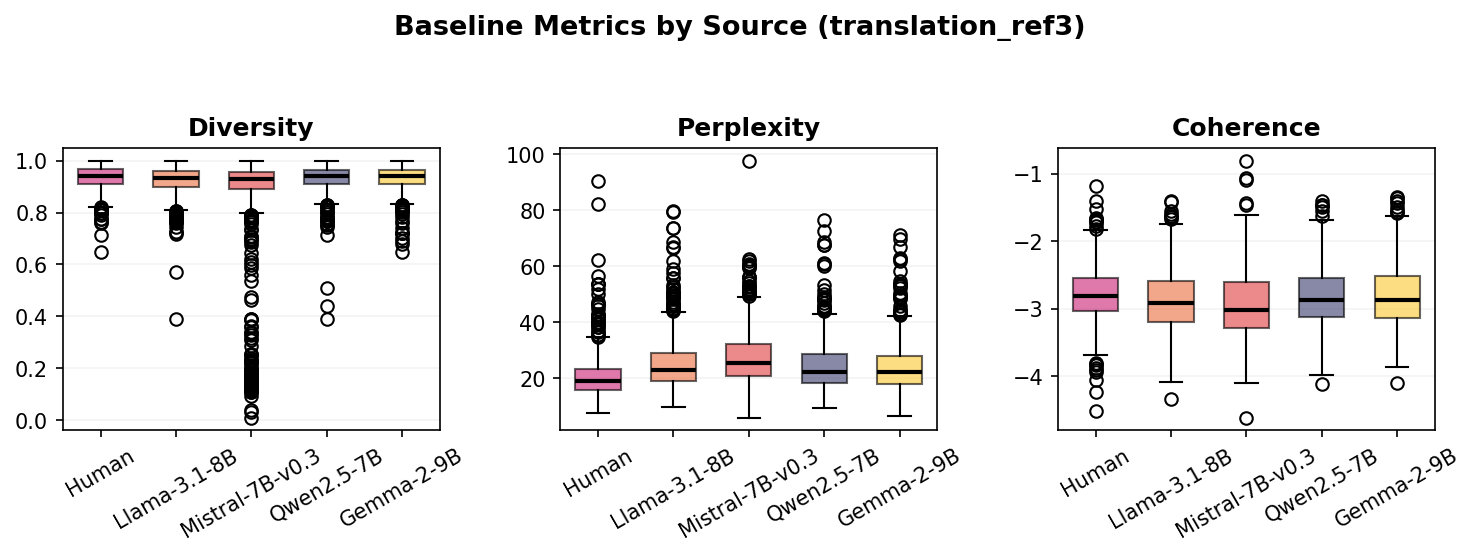

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

labels_plot = [MODEL_LABELS[s] for s in SOURCES]
colors_plot = [MODEL_COLORS[l] for l in labels_plot]

for ax, metric in zip(axes, METRICS):
    data_plot = [df[df['source'] == s][metric].dropna().values for s in SOURCES]
    bp = ax.boxplot(data_plot, labels=labels_plot, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2), widths=0.6)

    for patch, color in zip(bp['boxes'], colors_plot):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')

fig.suptitle(f'Baseline Metrics by Source ({DOMAIN})', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_metrics_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

## Metric Intercorrelations

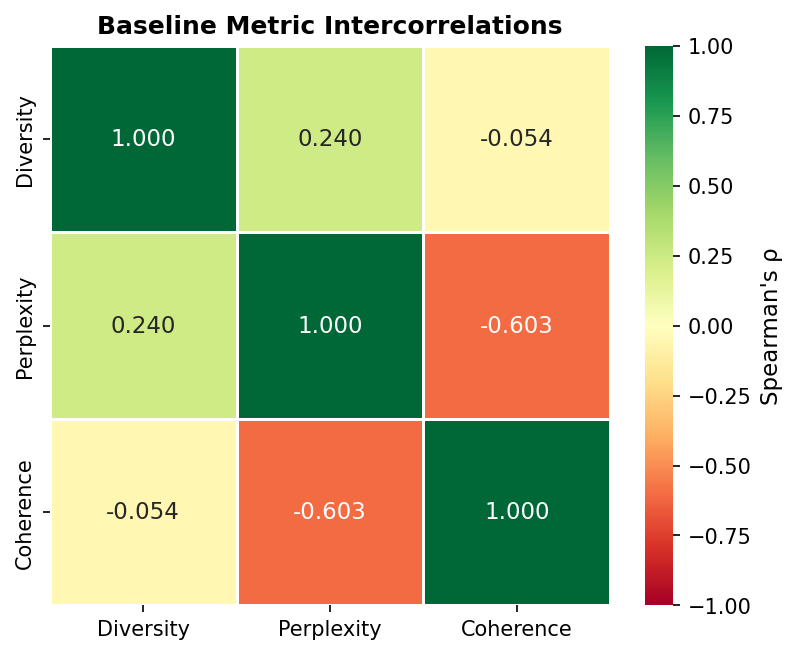

In [14]:
corr_df = df[METRICS].dropna()
rho_matrix = corr_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(rho_matrix, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': "Spearman's ρ"})
ax.set_title('Baseline Metric Intercorrelations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_metrics_intercorrelation.png', dpi=300, bbox_inches='tight')
plt.show()

## Q*Text: Unified Quality Score (Garces Arias et al., 2025)

$$\text{Q*Text} = \frac{\sum_{i=1}^{3} w_i M_i P_i(M_i)}{\sum_{i=1}^{3} w_i}, \qquad P_i(x) = \exp(-\alpha_i (x-\mu_i)^2)$$

- $M_1, M_2, M_3$ are Perplexity, Coherence and Diversity, each min-max normalized to $[0,1]$ over this dataset (Perplexity inverted so higher = better)
- $w_i$, $\mu_i$, $\alpha_i$ are weights, target values and penalty strengths per metric
- Result ×100 to match the paper's reported score range

**Parameters (paper's own fitted values)**:

| | Perplexity ($i=1$) | Coherence ($i=2$) | Diversity ($i=3$) |
|---|---|---|---|
| $w_i$ | 0.586 | 0.834 | 3.853 |
| $\mu_i$ | 0.458 | 0.000 | 0.854 |
| $\alpha_i$ | 2.579 | 1.496 | 7.370 |

In [15]:
# Fitted hyperparameters from Garces Arias et al. (2025)
Q_STAR_PARAMS = {
    # order in each tuple: (Perplexity, Coherence, Diversity)
    'w':     (0.586, 0.834, 3.853),   # weight: how much each metric contributes to the final score
    'mu':    (0.458, 0.000, 0.854),   # target: the "ideal" normalized value for each metric
    'alpha': (2.579, 1.496, 7.370),   # penalty strength: how sharply the score drops away from mu
}


def gaussian_penalty(x, mu, alpha):
    """P_i(x) = exp(-alpha * (x - mu)^2).

    - Equals 1.0 at x == mu and decays towards 0 the further x is from mu.
    - Large alpha -> narrow peak (strict), small alpha -> wide peak (lenient).
    """
    return np.exp(-alpha * (x - mu) ** 2)


def minmax_bounds(x, name):
    """Dataset-wide min/max for one raw metric column, NaN- and zero-range-safe.

    - skipna=True (pandas' default) means texts with a missing raw metric 
      are excluded from the min/max
    - If every valid value is identical (zero-width range, e.g. a degenerate subgroup with
      a single text), min-max normalization is undefined (0/0). Flag this instead of letting
      it silently divide by zero into inf/NaN.
    """

    # Compute the min and max of the series, skipping NaN values
    lo, hi = x.min(skipna=True), x.max(skipna=True)

    # Check for degenerate range (min == max) or if min is NaN
    degenerate = pd.isna(lo) or hi == lo

    # Warn if the range is degenerate, and normalize all valid values to the neutral midpoint 0.5 instead of dividing by zero
    if degenerate:
        warnings.warn(f'{name}: degenerate range (min == max == {lo}); normalizing all valid '
                       'values to the neutral midpoint 0.5 instead of dividing by zero')
    
    return lo, hi, degenerate


def compute_qstar(perplexity, coherence, diversity, params=Q_STAR_PARAMS):
    # Step 1: normalize each raw metric to [0, 1] over the current dataset,
    # so all three become directly comparable and "higher = better" for all of them

    p_min, p_max, p_degenerate = minmax_bounds(perplexity, 'Perplexity')
    c_min, c_max, c_degenerate = minmax_bounds(coherence, 'Coherence')
    d_min, d_max, d_degenerate = minmax_bounds(diversity, 'Diversity')

    # Neutral midpoint (0.5) for a degenerate range, kept NaN wherever the raw value itself
    # was NaN; otherwise the standard min-max ratio (raw LOWER is better for Perplexity, so
    # that one is flipped)
    m1 = pd.Series(0.5, index=perplexity.index).where(perplexity.notna()) if p_degenerate \
        else (p_max - perplexity) / (p_max - p_min)
    m2 = pd.Series(0.5, index=coherence.index).where(coherence.notna()) if c_degenerate \
        else (coherence - c_min) / (c_max - c_min)
    m3 = pd.Series(0.5, index=diversity.index).where(diversity.notna()) if d_degenerate \
        else (diversity - d_min) / (d_max - d_min)
    
    w1, w2, w3 = params['w']
    mu1, mu2, mu3 = params['mu']
    a1, a2, a3 = params['alpha']

    # Step 2: apply the Gaussian penalty to each normalized metric
    p1 = gaussian_penalty(m1, mu1, a1)
    p2 = gaussian_penalty(m2, mu2, a2)
    p3 = gaussian_penalty(m3, mu3, a3)

    # Step 3: weighted average of (metric value * its own penalty). 
    numerator = w1 * m1 * p1 + w2 * m2 * p2 + w3 * m3 * p3

    # Step 4: scale to [0, 100] for interpretability (0 = worst, 100 = best)
    return 100 * numerator / (w1 + w2 + w3)

# Compute Q*Text for each text in the dataset
df['QStarText'] = compute_qstar(df['Perplexity'], df['Coherence'], df['Diversity'])

print(df['QStarText'].describe())

count    4403.000000
mean       74.261744
std         8.875953
min         0.545788
25%        75.101589
50%        76.073552
75%        76.542590
max        77.370106
Name: QStarText, dtype: float64


In [16]:
# Overwrite the results CSVs
df.to_csv(CACHE_PATH, index=False)

df[['prompt_id', 'source', 'story_id', 'model', 'Diversity', 'Perplexity', 'Coherence', 'QStarText']].to_csv(
    TABLE_DIR / f'baseline_metrics_results_summary_{MODEL_TAG}_mt{MAX_TOKENS}.csv', index=False
)
print('Updated baseline_metrics_results.csv / _summary.csv with QStarText')

Updated baseline_metrics_results.csv / _summary.csv with QStarText


In [17]:
# Mean/std of all four metrics per source
ALL_METRICS = METRICS + ['QStarText']

summary_q = df.groupby('source')[ALL_METRICS].agg(['mean', 'std']).round(3)
summary_q = summary_q.loc[SOURCES]
summary_q.index = [MODEL_LABELS[s] for s in SOURCES]
summary_q

Diversity        Perplexity        Coherence        QStarText  \
                     mean    std       mean    std      mean    std      mean   
Human               0.934  0.045     20.660  8.274    -2.792  0.400    75.515   
Llama-3.1-8B        0.923  0.052     24.872  9.123    -2.882  0.442    75.247   
Mistral-7B-v0.3     0.866  0.205     27.062  9.271    -2.952  0.479    70.140   
Qwen2.5-7B          0.930  0.052     24.084  8.672    -2.827  0.431    75.462   
Gemma-2-9B          0.932  0.046     23.602  8.520    -2.818  0.455    75.538   

                         
                    std  
Human             2.208  
Llama-3.1-8B      3.273  
Mistral-7B-v0.3  17.377  
Qwen2.5-7B        3.831  
Gemma-2-9B        2.518

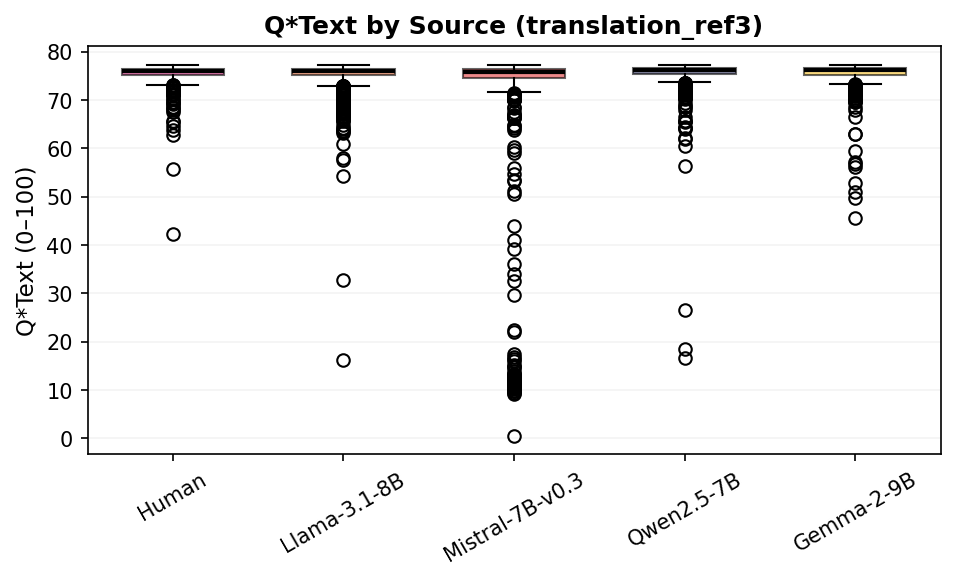

In [18]:
# Boxplot of Q*Text per source

fig, ax = plt.subplots(figsize=(6.5, 4))
labels_plot = [MODEL_LABELS[s] for s in SOURCES]
colors_plot = [MODEL_COLORS[l] for l in labels_plot]
data_plot = [df[df['source'] == s]['QStarText'].dropna().values for s in SOURCES]

bp = ax.boxplot(data_plot, labels=labels_plot, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2), widths=0.6)

for patch, color in zip(bp['boxes'], colors_plot):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title(f'Q*Text by Source ({DOMAIN})', fontsize=12, fontweight='bold')
ax.set_ylabel('Q*Text (0–100)')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'qstartext_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

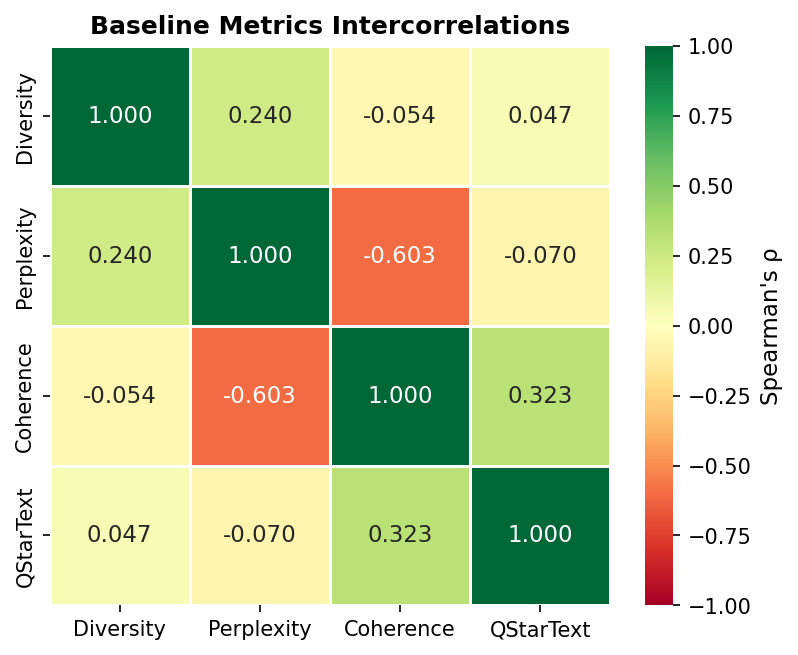

In [19]:
corr_all = df[['Diversity', 'Perplexity', 'Coherence', 'QStarText']].dropna().corr(method='spearman')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr_all, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': "Spearman's ρ"})
ax.set_title('Baseline Metrics Intercorrelations', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'qstartext_intercorrelation.png', dpi=300, bbox_inches='tight')
plt.show()

## Robustness Check: `MAX_TOKENS = 256`

- `MAX_TOKENS = 256` matches the paper's own generation cap (was generated under this cap)
- Reruns Perplexity on a random subsample using a sliding window across the full (untruncated) text up to the scorer's real context window (`CTX_LIMIT`, 2048 tokens for OPT-2.7B)
- Each window after the first only contributes loss for its new (non-overlapping) tokens, so no token is double-counted
- Overlap (`STRIDE`) just gives the model prior context for tokens near a window boundary
- Also reports how many of the sampled texts actually exceed `MAX_TOKENS` tokens (only those are where the truncation in `compute_perplexity` could have mattered in the first place)
- Run on a random subsample per source (not the full corpus) since scoring full-length texts is much slower than the single-window version

In [20]:
SLIDING_WINDOW = CTX_LIMIT          # full context window instead of MAX_TOKENS=256
STRIDE = SLIDING_WINDOW // 2        # 50% overlap: enough prior context near each window boundary
N_ROBUSTNESS_SAMPLE = 60            # texts per source (subsample - full-length scoring is slow)

# Cached separately from the main results (different key rows: only the robustness subsample,
# plus window/stride/corpus fingerprint in the filename since any of these changes the value)
ROBUSTNESS_CACHE_PATH = TABLE_DIR / f'perplexity_robustness_sliding_{MODEL_TAG}_w{SLIDING_WINDOW}_s{STRIDE}_{DATA_FINGERPRINT}.csv'


@torch.no_grad()
def compute_perplexity_sliding(text, window=SLIDING_WINDOW, stride=STRIDE):
    '''Perplexity over the full text via a sliding window, instead of truncating to
    MAX_TOKENS. Only each window's non-overlapping "new" tokens contribute loss, so
    overlap gives context without double-counting.
    '''

    # Tokenize the text without truncation, so we can slide over the entire sequence
    input_ids = tokenizer(text, return_tensors='pt', truncation=False)['input_ids'].to(DEVICE)
    seq_len = input_ids.shape[1]

    # Only compute perplexity if the text has at least 2 tokens (otherwise loss is undefined)
    if seq_len < 2:
        return np.nan

    nll_sum, n_tokens = 0.0, 0
    prev_end = 0

    # Slide a window over the tokenized input, computing loss for each window's new tokens
    for start in range(0, seq_len, stride):
        end = min(start + window, seq_len)
        # How many tokens at the START of this window were already scored as some
        # earlier window's "new" tokens -> only run the loss on the remainder
        trg_len = end - prev_end

        window_ids = input_ids[:, start:end]
        # labels: mask out the tokens this window is only providing as context (-100 is
        # ignored by the cross-entropy loss), keep only the new tokens' targets
        target_ids = window_ids.clone()
        target_ids[:, :-trg_len] = -100


        # Compute the loss for this window, which is averaged over the number of predicted tokens
        loss = model(window_ids, labels=target_ids).loss

        # loss is averaged over (trg_len - 1) predicted tokens (the first target token has
        # no prediction slot), so undo the averaging before accumulating
        num_loss_tokens = trg_len - (1 if start == 0 else 0)
        nll_sum += float(loss.cpu()) * num_loss_tokens
        n_tokens += num_loss_tokens

        # Update the previous window's end index for the next iteration
        prev_end = end
        if end == seq_len:
            break

    return float(np.exp(nll_sum / n_tokens))


# Stratified random subsample: N_ROBUSTNESS_SAMPLE texts per source
sample_idx = (
    df.groupby('source', group_keys=False)
      .apply(lambda g: g.sample(n=min(N_ROBUSTNESS_SAMPLE, len(g)), random_state=42))
      .index
)

# Create a new DataFrame for the robustness subsample, containing only the relevant columns
robustness_df = df.loc[sample_idx, ['prompt_id', 'source', 'story_id', 'model', 'text', 'Perplexity']].copy()

# Load cached sliding-window perplexity + full token count if available
if ROBUSTNESS_CACHE_PATH.exists():
    cached = pd.read_csv(ROBUSTNESS_CACHE_PATH)
    for col in ['PerplexitySliding', 'n_tokens']:
        if col not in cached.columns:
            cached[col] = np.nan
    robustness_df = robustness_df.merge(cached[KEY_COLS + ['PerplexitySliding', 'n_tokens']], on=KEY_COLS, how='left')

else:
    robustness_df['PerplexitySliding'] = np.nan
    robustness_df['n_tokens'] = np.nan

# Compute sliding-window perplexity and full token count for any texts that are missing these values
missing_ppl = robustness_df['PerplexitySliding'].isna()
if missing_ppl.any():
    robustness_df.loc[missing_ppl, 'PerplexitySliding'] = (
        robustness_df.loc[missing_ppl, 'text'].progress_apply(compute_perplexity_sliding)
    )

# Full (untruncated) token count per text -- tokenization only, no model forward pass
missing_tokens = robustness_df['n_tokens'].isna()
if missing_tokens.any():
    robustness_df.loc[missing_tokens, 'n_tokens'] = robustness_df.loc[missing_tokens, 'text'].apply(
        lambda t: tokenizer(t, return_tensors='pt', truncation=False)['input_ids'].shape[1]
    )

robustness_df[KEY_COLS + ['PerplexitySliding', 'n_tokens']].to_csv(ROBUSTNESS_CACHE_PATH, index=False)

n_over = (robustness_df['n_tokens'] > MAX_TOKENS).sum()
print(f'Sliding-window Perplexity for {len(robustness_df)} texts '
      f'({N_ROBUSTNESS_SAMPLE}/source, window={SLIDING_WINDOW}, stride={STRIDE}) '
      f'-- {(~missing_ppl).sum()} from cache, {missing_ppl.sum()} newly computed')
print(f'{n_over}/{len(robustness_df)} texts ({n_over / len(robustness_df):.1%}) exceed '
      f'MAX_TOKENS={MAX_TOKENS} OPT tokens -- these are the ones compute_perplexity above '
      f'was actually truncating')
print(f'Cached to: {ROBUSTNESS_CACHE_PATH}')
robustness_df[['Perplexity', 'PerplexitySliding', 'n_tokens']].describe()

100%|██████████| 300/300 [17:28<00:00,  3.49s/it] 


Sliding-window Perplexity for 300 texts (60/source, window=2048, stride=1024) -- 0 from cache, 300 newly computed
253/300 texts (84.3%) exceed MAX_TOKENS=256 OPT tokens -- these are the ones compute_perplexity above was actually truncating
Cached to: ../../metrics/04_baseline_metrics/tables/translation_ref3/perplexity_robustness_sliding_opt-2.7b_w2048_s1024_d343da2915178f56.csv


,Perplexity,PerplexitySliding,n_tokens
count,300.000000,300.000000,300.000000
mean,23.852262,21.024134,531.750000
std,9.220211,8.170908,511.934198
min,5.899046,2.180835,95.000000
25%,18.202377,16.007831,295.000000
50%,21.657152,19.675242,399.500000
75%,27.696707,24.657281,587.000000
max,82.273453,60.146351,5631.000000


Spearman's rho (256-token vs. sliding-window Perplexity): 0.854 (p=0.0000)
Mean relative difference (sliding - truncated) / truncated: -10.6% (std 16.0%)

Per-source mean Perplexity: 256-token cap vs. full-text sliding window
                 Perplexity  PerplexitySliding  rank_truncated  rank_sliding
Human                 20.54              17.32             1.0           1.0
Llama-3.1-8B          24.46              22.13             3.0           3.0
Mistral-7B-v0.3       26.64              22.19             5.0           4.0
Qwen2.5-7B            25.04              23.07             4.0           5.0
Gemma-2-9B            22.59              20.42             2.0           2.0


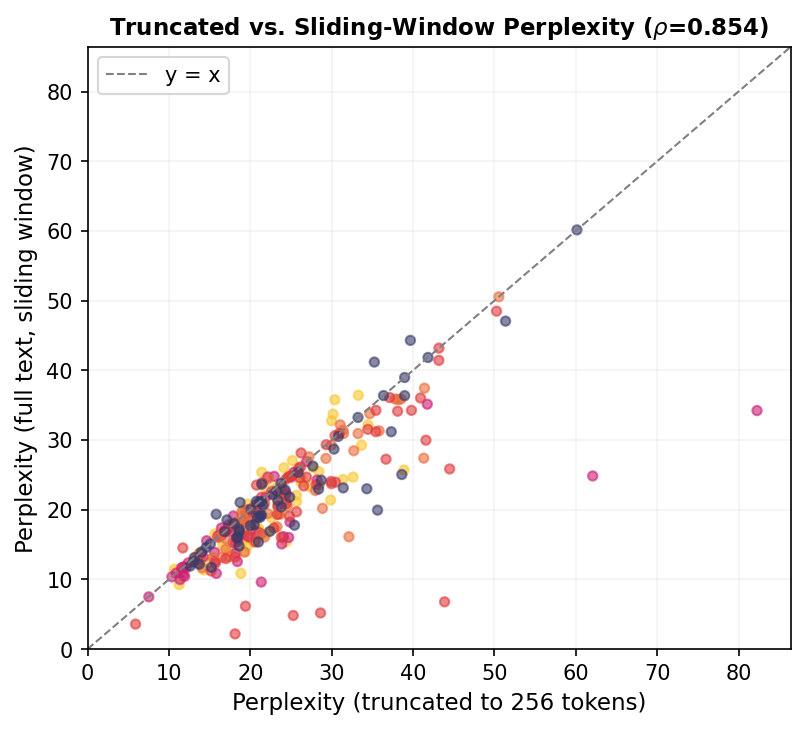

In [22]:
from scipy.stats import spearmanr

# Agreement between the 256-token truncated version and the full-text sliding-window version
rho, rho_p = spearmanr(robustness_df['Perplexity'], robustness_df['PerplexitySliding'])
rel_diff = (robustness_df['PerplexitySliding'] - robustness_df['Perplexity']) / robustness_df['Perplexity']

print(f"Spearman's rho (256-token vs. sliding-window Perplexity): {rho:.3f} (p={rho_p:.4f})")
print(f'Mean relative difference (sliding - truncated) / truncated: {rel_diff.mean():+.1%} '
      f'(std {rel_diff.std():.1%})')

# Check ranking agreement between the two Perplexity versions
rank_compare = (
    robustness_df.groupby('source')[['Perplexity', 'PerplexitySliding']]
    .mean().loc[SOURCES].round(2)
)
rank_compare.index = [MODEL_LABELS[s] for s in SOURCES]
rank_compare['rank_truncated'] = rank_compare['Perplexity'].rank()
rank_compare['rank_sliding'] = rank_compare['PerplexitySliding'].rank()


print('\nPer-source mean Perplexity: 256-token cap vs. full-text sliding window')
print(rank_compare)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(robustness_df['Perplexity'], robustness_df['PerplexitySliding'],
           c=[MODEL_COLORS[MODEL_LABELS[s]] for s in robustness_df['source']], alpha=0.6, s=20)
lims = [0, max(robustness_df['Perplexity'].max(), robustness_df['PerplexitySliding'].max()) * 1.05]
ax.plot(lims, lims, color='grey', linestyle='--', linewidth=1, label='y = x')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(f'Perplexity (truncated to {MAX_TOKENS} tokens)')
ax.set_ylabel('Perplexity (full text, sliding window)')
ax.set_title(f"Truncated vs. Sliding-Window Perplexity ($\\rho$={rho:.3f})", fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig(FIG_DIR / 'perplexity_robustness_sliding_window.png', dpi=300, bbox_inches='tight')
plt.show()